# Notebook 03 — Treino do Modelo: ConvNeXt Tiny

Este notebook implementa o treino de um **ConvNeXt Tiny** com Transfer Learning sobre o dataset MIQR-CC pré-processado (Notebooks 01 e 02).

A **ConvNeXt** é uma arquitectura de rede neural convolucional moderna introduzida pela **Meta (Facebook AI Research) em 2022**, concebida para rivalizar com os Vision Transformers. Inspirada no design do Swin Transformer, a ConvNeXt moderniza a arquitectura ResNet clássica com blocos convolucionais maiores, normalização por camada (LayerNorm) e funções de activação GELU. A variante **Tiny** oferece um equilíbrio eficiente entre desempenho e custo computacional.

**Pipeline:**
1. Autenticar e configurar o Weights & Biases (WandB)
2. Carregar os CSVs do split (Train / Val / Test)
3. Configurar pesos de classes para lidar com o desequilíbrio
4. Definir Dataset e Transforms (224×224, normalização ImageNet)
5. Instanciar o modelo ConvNeXt Tiny com pesos pré-treinados em ImageNet
6. Treinar com estratégia de Fine-Tuning em 2 fases e registo no WandB
7. Avaliar no Test Set — F1-Score Macro, AUC-ROC e Matriz de Confusão

---


## 0. Login no WandB

Antes de executar este notebook pela primeira vez, autentique-se no Weights & Biases:
```bash
wandb login
```
Introduza a API Key quando solicitado. Este passo só é necessário **uma vez** por ambiente.


## 1. Importações


In [27]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import timm                          # Biblioteca com os modelos mais modernos (inclui ConvNeXt Tiny)
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F

import wandb

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('Importações concluídas!')


Dispositivo: cuda
GPU: Tesla T4
Importações concluídas!


## 2. Carregar os CSVs do Split (Fase 1)


In [28]:
DATA_DIR = '/kaggle/input/datasets/helenaoliveira04/dataset/'
CSV_DIR  = '/kaggle/input/datasets/helenaoliveira04/dataset/processed'

df_train = pd.read_csv(os.path.join(CSV_DIR, 'train_split.csv'))
df_val   = pd.read_csv(os.path.join(CSV_DIR, 'val_split.csv'))
df_test  = pd.read_csv(os.path.join(CSV_DIR, 'test_split.csv'))

# Classes ordenadas alfabeticamente
class_names = sorted(df_train['Label'].unique().tolist())
num_classes = len(class_names)
label2idx   = {label: i for i, label in enumerate(class_names)}
idx2label   = {i: label for label, i in label2idx.items()}

print(f'Classes ({num_classes}): {class_names}')
print(f'Mapeamento: {label2idx}')
print(f'\nDimensões do dataset:')
print(f'  Treino:    {len(df_train)} imagens')
print(f'  Validação: {len(df_val)} imagens')
print(f'  Teste:     {len(df_test)} imagens')
print(f'  Total:     {len(df_train)+len(df_val)+len(df_test)} imagens')

print('\nDistribuição do Treino:')
dist = df_train['Label'].value_counts()
for cls, count in dist.items():
    print(f'  {cls}: {count} ({100*count/len(df_train):.1f}%)')


Classes (4): ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']
Mapeamento: {'Biliary Leaks': 0, 'Lithiasis': 1, 'Normal': 2, 'Stricture': 3}

Dimensões do dataset:
  Treino:    1067 imagens
  Validação: 234 imagens
  Teste:     267 imagens
  Total:     1568 imagens

Distribuição do Treino:
  Lithiasis: 505 (47.3%)
  Stricture: 255 (23.9%)
  Normal: 197 (18.5%)
  Biliary Leaks: 110 (10.3%)


## 3. Class Weights (Lidar com Desequilíbrio de Classes)


In [29]:
y_train = df_train['Label'].map(label2idx).values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print('Pesos calculados por classe (quanto mais alto = mais raro):')
for cls, w in zip(class_names, class_weights):
    bar = '█' * int(w * 5)
    print(f'  {cls:12s}: {w:.4f}  {bar}')


Pesos calculados por classe (quanto mais alto = mais raro):
  Biliary Leaks: 2.4250  ████████████
  Lithiasis   : 0.5282  ██
  Normal      : 1.3541  ██████
  Stricture   : 1.0461  █████


## 4. Dataset e Transforms

As imagens em `data/processed/` já foram sujeitas a CLAHE e normalização no Notebook 02.  
O ConvNeXt Tiny usa imagens 224×224 com normalização ImageNet.


In [30]:
IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transforms de Treino (com Data Augmentation)
train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.1),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transforms de Validação/Teste (sem augmentation)
val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print(f'Transforms definidos para imagens {IMG_SIZE}x{IMG_SIZE}.')


Transforms definidos para imagens 224x224.


In [31]:
class ERCPDataset(Dataset):
    """Dataset MIQR-CC carregado a partir dos CSVs do split."""

    def __init__(self, df, data_dir, label2idx, transforms):
        self.df         = df.reset_index(drop=True)
        self.data_dir   = data_dir
        self.label2idx  = label2idx
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row['processed_image_path'])
        label    = self.label2idx[row['Label']]
        img      = Image.open(img_path).convert('RGB')
        img      = self.transforms(img)
        return img, label


BATCH_SIZE = 16   # Reduz para 8 se deres Out of Memory

train_dataset = ERCPDataset(df_train, DATA_DIR, label2idx, train_transforms)
val_dataset   = ERCPDataset(df_val,   DATA_DIR, label2idx, val_transforms)
test_dataset  = ERCPDataset(df_test,  DATA_DIR, label2idx, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'DataLoaders criados (batch_size={BATCH_SIZE}):')
print(f'  Treino:    {len(train_loader)} batches  ({len(train_dataset)} imagens)')
print(f'  Validação: {len(val_loader)} batches  ({len(val_dataset)} imagens)')
print(f'  Teste:     {len(test_loader)} batches  ({len(test_dataset)} imagens)')

# Verificação rápida
imgs, labels = next(iter(train_loader))
print(f'\nShape de uma batch: imgs={imgs.shape}, labels={labels.shape}')


DataLoaders criados (batch_size=16):
  Treino:    67 batches  (1067 imagens)
  Validação: 15 batches  (234 imagens)
  Teste:     17 batches  (267 imagens)

Shape de uma batch: imgs=torch.Size([16, 3, 224, 224]), labels=torch.Size([16])


## 5. Criar o Modelo: ConvNeXt Tiny

O modelo **ConvNeXt Tiny** é carregado via `timm` com pesos pré-treinados em **ImageNet-1k**. É a variante mais eficiente da família ConvNeXt, oferecendo um bom equilíbrio entre capacidade representacional e custo computacional.


In [32]:
MODEL_NAME = 'convnext_tiny'

def build_convnext(num_classes, freeze_backbone=True):
    """
    Cria um ConvNeXt Tiny pré-treinado.
    O timm substitui automaticamente a camada de saída (head) com num_classes.
    """
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=num_classes
    )

    if freeze_backbone:
        # Congelar todo o backbone (bloqueando tudo que não é da classifier head)
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False

    # Ajustar o dropout do classificador head original
    model.head.drop = nn.Dropout(p=0.4)
    return model.to(device)


model = build_convnext(num_classes, freeze_backbone=True)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo: {MODEL_NAME}')
print(f'Parâmetros totais:     {total:,}')
print(f'Parâmetros treináveis: {trainable:,} ({100*trainable/total:.2f}%)')
print(f'\nCamada de saída (head):')
print(model.head)


Modelo: convnext_tiny
Parâmetros totais:     27,823,204
Parâmetros treináveis: 4,612 (0.02%)

Camada de saída (head):
NormMlpClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (norm): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (pre_logits): Identity()
  (drop): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=768, out_features=4, bias=True)
)


## 6. Treino com WandB

Estratégia de Fine-Tuning em 2 fases:
- **Fase 1 (épocas 1–5):** Backbone congelado, só treina o classificador com `lr=1e-3`
- **Fase 2 (épocas 6+):** Backbone descongelado, fine-tuning completo com `lr=1e-5` e CosineAnnealing
- **Early Stopping** com paciência de 7 épocas sem melhoria no Val F1-Macro


In [33]:
def train_convnext(
    wandb_project,
    wandb_entity,
    epochs_phase1=5,
    epochs_phase2=30,
    lr_phase1=1e-3,
    lr_phase2=5e-5,
    patience=10
):
    # ── WandB ──────────────────────────────────────────────────
    run = wandb.init(
        project=wandb_project,
        entity=wandb_entity,
        name='ConvNeXt-Tiny',
        config={
            'model': MODEL_NAME,
            'img_size': IMG_SIZE,
            'batch_size': BATCH_SIZE,
            'epochs_phase1': epochs_phase1,
            'epochs_phase2': epochs_phase2,
            'lr_phase1': lr_phase1,
            'lr_phase2': lr_phase2,
            'optimizer': 'AdamW',
            'loss': 'CrossEntropyLoss (weighted)',
            'early_stopping_patience': patience,
            'num_classes': num_classes,
            'classes': class_names,
            'seed': SEED
        }
    )

    loss_fn   = nn.CrossEntropyLoss(weight=class_weights_tensor)
    save_path = './models/convnext_tiny_best.pth'

    best_val_f1    = -1.0
    epochs_no_impr = 0

    # ── Função de uma época ────────────────────────────────────
    def run_epoch(model, loader, optimizer=None, training=True):
        model.train() if training else model.eval()
        total_loss = 0.0
        y_true, y_pred, y_probs = [], [], []

        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                if training:
                    optimizer.zero_grad()
                outputs = model(imgs)
                loss    = loss_fn(outputs, labels)
                if training:
                    loss.backward()
                    optimizer.step()

                total_loss += loss.item() * imgs.size(0)
                probs  = F.softmax(outputs, dim=1)
                preds  = probs.argmax(dim=1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
                y_probs.extend(probs.detach().cpu().numpy())

        avg_loss = total_loss / len(loader.dataset)
        f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
        acc = (np.array(y_true) == np.array(y_pred)).mean()
        return avg_loss, f1, acc, np.array(y_true), np.array(y_pred), np.array(y_probs)

    # ── FASE 1: Backbone congelado ─────────────────────────────
    print('='*65)
    print('FASE 1 — Treino do classificador (backbone congelado)')
    print('='*65)

    model     = build_convnext(num_classes, freeze_backbone=True)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_phase1, weight_decay=1e-3
    )

    for epoch in range(1, epochs_phase1 + 1):
        tr_loss, tr_f1, tr_acc, *_ = run_epoch(model, train_loader, optimizer, training=True)
        vl_loss, vl_f1, vl_acc, *_ = run_epoch(model, val_loader, training=False)
        wandb.log({'epoch': epoch, 'phase': 1,
                   'train_loss': tr_loss, 'train_f1_macro': tr_f1, 'train_accuracy': tr_acc,
                   'val_loss':   vl_loss, 'val_f1_macro':   vl_f1, 'val_accuracy':   vl_acc})
        print(f'[F1|Ep {epoch:02d}] Train Loss={tr_loss:.4f} F1={tr_f1:.4f} | '
              f'Val Loss={vl_loss:.4f} F1={vl_f1:.4f}')

    # ── FASE 2: Fine-Tuning completo ───────────────────────────
    print('\n' + '='*65)
    print('FASE 2 — Fine-Tuning completo (backbone descongelado)')
    print('='*65)

    for param in model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_phase2, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_phase2)

    for epoch in range(1, epochs_phase2 + 1):
        global_ep = epochs_phase1 + epoch
        tr_loss, tr_f1, tr_acc, *_ = run_epoch(model, train_loader, optimizer, training=True)
        vl_loss, vl_f1, vl_acc, vl_true, vl_pred, vl_probs = run_epoch(model, val_loader, training=False)
        scheduler.step()

        # AUC-ROC na validação (multi-classe)
        try:
            vl_auc = roc_auc_score(
                vl_true, vl_probs, multi_class='ovr', average='macro'
            )
        except Exception:
            vl_auc = 0.0

        wandb.log({'epoch': global_ep, 'phase': 2,
                   'train_loss': tr_loss, 'train_f1_macro': tr_f1, 'train_accuracy': tr_acc,
                   'val_loss':   vl_loss, 'val_f1_macro':   vl_f1, 'val_accuracy':   vl_acc,
                   'val_auc_roc': vl_auc,
                   'lr': optimizer.param_groups[0]['lr']})

        print(f'[F2|Ep {global_ep:02d}] Train Loss={tr_loss:.4f} F1={tr_f1:.4f} | '
              f'Val Loss={vl_loss:.4f} F1={vl_f1:.4f} AUC={vl_auc:.4f}')

        if vl_f1 > best_val_f1:
            best_val_f1    = vl_f1
            epochs_no_impr = 0
            torch.save(model.state_dict(), save_path)
            print(f'  ✓ Novo melhor modelo guardado! Val F1={best_val_f1:.4f}')
        else:
            epochs_no_impr += 1
            if epochs_no_impr >= patience:
                print(f'\nEarly Stopping na época {global_ep}. '
                      f'Melhor Val F1: {best_val_f1:.4f}')
                break

    # ── AVALIAÇÃO FINAL NO TEST SET ────────────────────────────
    print('\n' + '='*65)
    print('AVALIAÇÃO FINAL NO TEST SET')
    print('='*65)

    model.load_state_dict(torch.load(save_path, map_location=device))
    _, _, _, ts_true, ts_pred, ts_probs = run_epoch(model, test_loader, training=False)

    test_f1 = f1_score(ts_true, ts_pred, average='macro', zero_division=0)
    try:
        test_auc = roc_auc_score(ts_true, ts_probs, multi_class='ovr', average='macro')
    except Exception:
        test_auc = 0.0

    print(f'\nF1-Score Macro (Test Set):  {test_f1:.4f}')
    print(f'AUC-ROC Macro  (Test Set):  {test_auc:.4f}')
    print(f'Baseline do Professor:       0.7380')
    print(f'Diferença face à baseline:  {test_f1 - 0.738:+.4f}')
    print('\nClassification Report:')
    print(classification_report(ts_true, ts_pred,
                                target_names=class_names, digits=4, zero_division=0))

    # Probabilidades por classe (Fase 4 do enunciado)
    print('\nExemplo de probabilidades para as primeiras 5 imagens de teste:')
    prob_df = pd.DataFrame(ts_probs[:5], columns=class_names)
    prob_df['Previsto'] = [class_names[p] for p in ts_pred[:5]]
    prob_df['Real']     = [class_names[t] for t in ts_true[:5]]
    print(prob_df.to_string(index=False))

    # Matriz de Confusão
    cm  = confusion_matrix(ts_true, ts_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Previsto');  ax.set_ylabel('Real')
    ax.set_title('Matriz de Confusão — ConvNeXt Tiny')
    plt.tight_layout()

    # Log final no WandB
    wandb.log({
        'test_f1_macro':  test_f1,
        'test_auc_macro': test_auc,
        'confusion_matrix': wandb.plot.confusion_matrix(
            probs=None, y_true=ts_true, preds=ts_pred,
            class_names=class_names
        ),
        'confusion_matrix_plot': wandb.Image(fig)
    })
    plt.show()
    run.finish()

    print('\nTreino concluído! Verifica os resultados em https://wandb.ai')
    return model


## 7. Lançar o Treino

**Antes de correr:**  
Certifica-te que a `venv` está ativa no terminal do VS Code.

O treino demora aproximadamente **45–90 minutos** em CPU ou **10–20 minutos** em GPU.


epoch,▁▂▄▅▇█
lr,▁
phase,▁▁▁▁▁█
train_accuracy,▁▅▇▇█▂
train_f1_macro,▁▅▇▇█▃
train_loss,█▅▂▁▁▅
val_accuracy,▁▅██▄█
val_auc_roc,▁
val_f1_macro,▁▁▇▅██
val_loss,█▇▂█▁▂
epoch,6


FASE 1 — Treino do classificador (backbone congelado)
[F1|Ep 01] Train Loss=1.5770 F1=0.2785 | Val Loss=1.4479 F1=0.2752
[F1|Ep 02] Train Loss=1.4003 F1=0.3721 | Val Loss=1.4377 F1=0.2735
[F1|Ep 03] Train Loss=1.2580 F1=0.4366 | Val Loss=1.3539 F1=0.3718
[F1|Ep 04] Train Loss=1.2117 F1=0.4352 | Val Loss=1.4519 F1=0.3336
[F1|Ep 05] Train Loss=1.2128 F1=0.4528 | Val Loss=1.3377 F1=0.3875

FASE 2 — Fine-Tuning completo (backbone descongelado)
[F2|Ep 06] Train Loss=1.4428 F1=0.3170 | Val Loss=1.3575 F1=0.3897 AUC=0.6617
  ✓ Novo melhor modelo guardado! Val F1=0.3897
[F2|Ep 07] Train Loss=1.0586 F1=0.5160 | Val Loss=1.5555 F1=0.2753 AUC=0.6977
[F2|Ep 08] Train Loss=0.8336 F1=0.6177 | Val Loss=1.2547 F1=0.4002 AUC=0.7531
  ✓ Novo melhor modelo guardado! Val F1=0.4002
[F2|Ep 09] Train Loss=0.5904 F1=0.7360 | Val Loss=1.4755 F1=0.4753 AUC=0.7408
  ✓ Novo melhor modelo guardado! Val F1=0.4753
[F2|Ep 10] Train Loss=0.5264 F1=0.7624 | Val Loss=1.3847 F1=0.4792 AUC=0.7669
  ✓ Novo melhor modelo gu

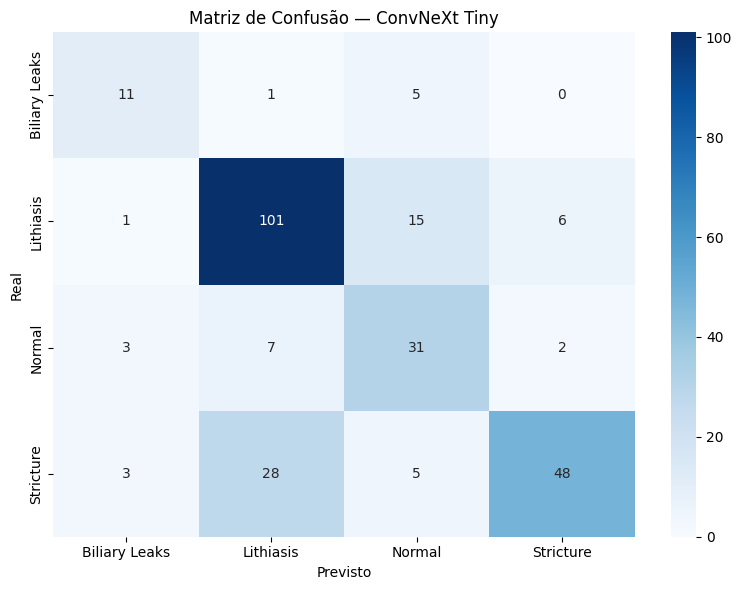

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁
phase,▁▁▁▁▁███████████████████████████
test_auc_macro,▁
test_f1_macro,▁
train_accuracy,▁▂▃▃▃▁▃▄▅▆▆▇▇▇▇▇████████████████
train_f1_macro,▁▂▃▃▃▁▃▄▅▆▆▇▇▇█▇████████████████
train_loss,█▇▇▆▆▇▆▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▄▄▂▄▁▄▅▅▅▅▆▆▆▆▇▄▅▆▆█▇▇▇▅▅▇▇▆▇▆
val_auc_roc,▁▃▅▅▆▅▅▇▆▇▆▇▅▅▆▇█▇▇▇▆▆█▇▇▇▇
+2,...



Treino concluído! Verifica os resultados em https://wandb.ai


In [34]:
trained_model = train_convnext(
    wandb_project='saraantunesferreirapinto-universidade-do-minho',
    wandb_entity='saraantunesferreirapinto-universidade-do-minho',
    epochs_phase1=5,
    epochs_phase2=30,
    lr_phase1=1e-3,
    lr_phase2=3e-5,
    patience=10
)


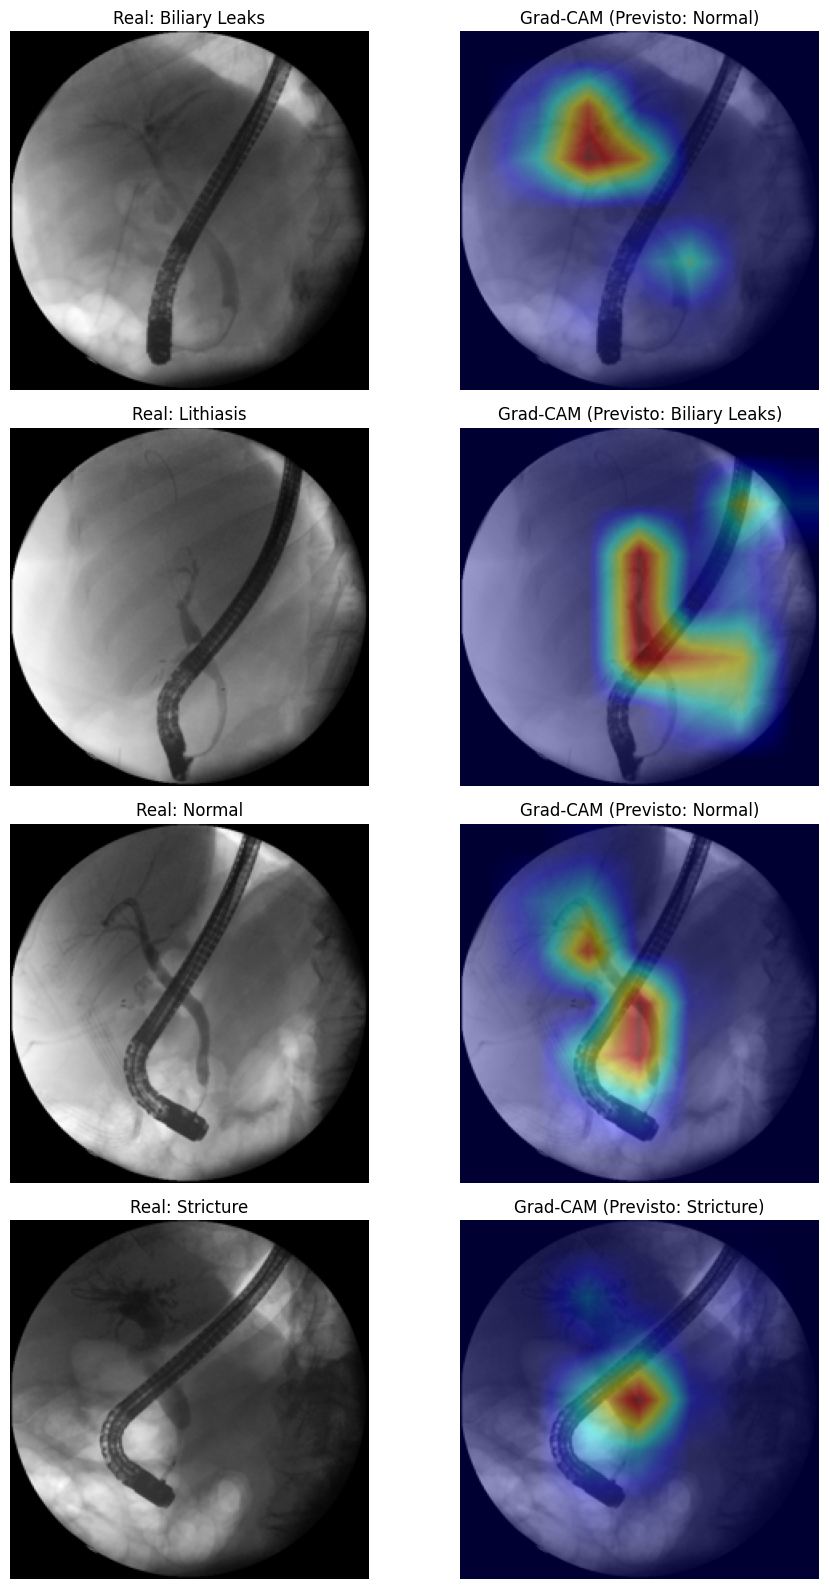

In [35]:
# ── SECÇÃO 8: Visualização e Interpretabilidade (Grad-CAM) ───────────────────
# O Grad-CAM (Gradient-weighted Class Activation Mapping) permite-nos visualizar em que regiões
# da imagem de fluoroscopia a ConvNeXt Tiny se focou para tomar a sua decisão.
# Para a ConvNeXt Tiny, extraímos os mapas da última camada convolucional ('layer4').

import cv2

class ConvNeXtGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Registar hooks para guardar as ativações e os gradientes
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
            
        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()
        
        # Pesos dos canais obtidos pela média global dos gradientes
        weights = torch.mean(self.gradients, dim=[2, 3])[0]
        
        # Combinação linear ponderada das ativações
        cam = torch.zeros(self.activations.shape[2:], dtype=torch.float32, device=input_tensor.device)
        for i, w in enumerate(weights):
            cam += w * self.activations[0, i, :, :]
            
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy(), class_idx

# Carregar o melhor modelo treinado
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = build_convnext(num_classes, freeze_backbone=False)
best_model.load_state_dict(torch.load('./models/convnext_tiny_best.pth', map_location=device))

# Inicializar o Grad-CAM visando a 'layer4' da ConvNeXt Tiny
grad_cam = ConvNeXtGradCAM(best_model, best_model.stages[-1].blocks[-1])

# Escolher 4 imagens do Test Set representativas (uma de cada classe)
representatives = []
for name in class_names:
    sample = df_test[df_test['Label'] == name].head(1)
    if not sample.empty:
        representatives.append(sample.iloc[0])

fig, axes = plt.subplots(len(representatives), 2, figsize=(10, 4 * len(representatives)))

for idx, row in enumerate(representatives):
    img_path = os.path.join(DATA_DIR, row['processed_image_path'])
    orig_img = Image.open(img_path).convert('RGB')
    input_tensor = val_transforms(orig_img).unsqueeze(0).to(device)
    
    # Gerar o heatmap do Grad-CAM
    mask, pred_idx = grad_cam(input_tensor)
    
    # Preparar a imagem original para sobreposição
    orig_np = np.array(orig_img.resize((224, 224)))
    mask_resized = cv2.resize(mask, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Sobreposição (60% imagem original, 40% mapa de calor)
    overlay = cv2.addWeighted(orig_np, 0.6, heatmap, 0.4, 0)
    
    # Plot da Imagem Original
    axes[idx, 0].imshow(orig_np)
    axes[idx, 0].set_title(f"Real: {row['Label']}")
    axes[idx, 0].axis('off')
    
    # Plot do Mapa de Calor Grad-CAM
    axes[idx, 1].imshow(overlay)
    axes[idx, 1].set_title(f"Grad-CAM (Previsto: {class_names[pred_idx]})")
    axes[idx, 1].axis('off')

plt.tight_layout()
# Guardar imagem para o relatório
plt.savefig('./models/convnext_gradcam_results.png', dpi=150)
plt.show()

# Log do mapa de calor no WandB para consulta online
wandb.init(
    project='saraantunesferreirapinto-universidade-do-minho',
    entity='saraantunesferreirapinto-universidade-do-minho',
    name='ConvNeXt Tiny-Grad-CAM-Plots',
    resume="allow"
)
wandb.log({"gradcam_results_plot_convnext": wandb.Image(fig)})
wandb.finish()
